# - STUDENT: LINETH GUERRA
# - TUITION: A01795639

In this notebook, you will implement a sentiment scoring pipeline using a Natural Language Inference (NLI) model.
You will analyze whether news headlines about S&P 500 companies have positive or negative sentiment and explore how this sentiment correlates with market returns.


## Install and Import librairies
Install necessary packages and import the required libraries for:
- Loading data
- Using transformer models
- Plotting and visualizing results
- Downloading financial data

In [1]:
%pip install hf_xet
%pip install yfinance

In [2]:
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import math
import matplotlib.pyplot as plt
import yfinance as yf
from sentence_transformers import CrossEncoder
import numpy as np
import seaborn as sns

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os
DIR = "/content/drive/MyDrive/FINTECH"
os.chdir(DIR)

Mounted at /content/drive


## Load news data
Load two datasets:
- `df_news.csv`: contains headlines and summaries
- `df_metadata.csv`: contains ticker symbols and company sector info

We drop duplicate summaries to avoid redundant sentiment scoring.

In [4]:
df_news = pd.read_csv('df_news.csv')
df_news.drop_duplicates('SUMMARY', inplace=True)
display(df_news)

,TICKER,TITLE,SUMMARY,PUBLICATION_DATE,PROVIDER,URL
0,MMM,2 Dow Jones Stocks with Promising Prospects an...,The Dow Jones (^DJI) is made up of 30 of the m...,2025-05-29 04:33:58+00:00,StockStory,https://finance.yahoo.com/news/2-dow-jones-sto...
1,MMM,3 S&P 500 Stocks Skating on Thin Ice,The S&P 500 (^GSPC) is often seen as a benchma...,2025-05-27 04:34:42+00:00,StockStory,https://finance.yahoo.com/news/3-p-500-stocks-...
2,MMM,3M Rises 15.8% YTD: Should You Buy the Stock N...,"MMM is making strides in the aerospace, indust...",2025-05-22 14:08:00+00:00,Zacks,https://finance.yahoo.com/news/3m-rises-15-8-y...
3,MMM,Q1 Earnings Roundup: 3M (NYSE:MMM) And The Res...,Quarterly earnings results are a good time to ...,2025-05-22 03:31:21+00:00,StockStory,https://finance.yahoo.com/news/q1-earnings-rou...
4,MMM,3 Cash-Producing Stocks with Questionable Fund...,While strong cash flow is a key indicator of s...,2025-05-19 04:41:32+00:00,StockStory,https://finance.yahoo.com/news/3-cash-producin...
...,...,...,...,...,...,...
4866,ZTS,2 Dividend Stocks to Buy With $500 and Hold Fo...,Zoetis is a leading animal health company with...,2025-05-23 10:30:00+00:00,Motley Fool,https://www.fool.com/investing/2025/05/23/2-di...
4867,ZTS,Zoetis (NYSE:ZTS) Declares US$0.50 Dividend Pe...,Zoetis (NYSE:ZTS) recently affirmed a dividend...,2025-05-22 17:49:43+00:00,Simply Wall St.,https://finance.yahoo.com/news/zoetis-nyse-zts...
4868,ZTS,Jim Cramer on Zoetis (ZTS): “It Does Seem to B...,We recently published a list of Jim Cramer Tal...,2025-05-21 18:14:38+00:00,Insider Monkey,https://finance.yahoo.com/news/jim-cramer-zoet...
4869,ZTS,Zoetis (ZTS) Upgraded to Buy: Here's Why,Zoetis (ZTS) might move higher on growing opti...,2025-05-21 16:00:08+00:00,Zacks,https://finance.yahoo.com/news/zoetis-zts-upgr...


In [5]:
df_meta = pd.read_csv('df_metadata.csv')
display(df_meta)

,TICKER,COMPANY_NAME,SECTOR,INDUSTRY
0,MMM,3M Company,Industrials,Conglomerates
1,AOS,A. O. Smith Corporation,Industrials,Specialty Industrial Machinery
2,ABT,Abbott Laboratories,Healthcare,Medical Devices
3,ABBV,AbbVie Inc.,Healthcare,Drug Manufacturers - General
4,ACN,Accenture plc,Technology,Information Technology Services
...,...,...,...,...
485,XEL,Xcel Energy Inc.,Utilities,Utilities - Regulated Electric
486,XYL,Xylem Inc.,Industrials,Specialty Industrial Machinery
487,YUM,"Yum! Brands, Inc.",Consumer Cyclical,Restaurants
488,ZBH,"Zimmer Biomet Holdings, Inc.",Healthcare,Medical Devices


## Sentiment Analysis with NLI

In this section, you will apply a CrossEncoder NLI model (`cross-encoder/nli-deberta-v3-base`) to estimate sentiment from news headlines.

👉 **Instructions**:

1. Use a CrossEncoder NLI model to compute how much a news headline implies a **positive** or **negative** sentiment.
2. For each news title, compute the probability of it being **positive** and **negative**, and store them in `POSITIVE_PROB` and `NEGATIVE_PROB`.
3. Derive a final sentiment score by subtracting: `SENTIMENT = POSITIVE_PROB - NEGATIVE_PROB`.

✅ This score will serve as your sentiment signal, ranging from negative to positive.

> ℹ️ You are free to decide how to structure the input pairs and how to apply the model.


In [6]:
from tqdm import tqdm

# Model configuration
MODEL_NAME = "cross-encoder/nli-deberta-v3-base"

# Load model/tokenizer and set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(device).eval()

# Map class indices to labels
if hasattr(model.config, "id2label"):
    label_map = {int(k): v for k, v in model.config.id2label.items()}
else:
    label_map = {0: "contradiction", 1: "neutral", 2: "entailment"}

# Find entailment index
entailment_candidates = [idx for idx, lbl in label_map.items() if "entail" in lbl.lower()]
assert len(entailment_candidates) == 1, f"Expected one entailment label, found: {label_map}"
ENTAILMENT_INDEX = entailment_candidates[0]

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/738M [00:00<?, ?B/s]

In [7]:
def compute_entailment_probabilities(texts, hypothesis, batch_size=32, max_length=256):

    results = []

    for start in tqdm(range(0, len(texts), batch_size), desc=f"Processing: {hypothesis[:25]}..."):
        batch = texts[start:start + batch_size]
        encodings = tokenizer(
            batch,
            [hypothesis] * len(batch),
            truncation=True,
            padding=True,
            max_length=max_length,
            return_tensors="pt"
        ).to(device)

        logits = model(**encodings).logits
        probs = torch.nn.functional.softmax(logits, dim=-1)[:, ENTAILMENT_INDEX]
        results.extend(probs.cpu().tolist())

    return results


# Sentiment Hypothese
hypothesis_positive = "Overall, this news is positive for the company."
hypothesis_negative = "Overall, this news is negative for the company."

# Prepare candidate texts
news_titles = df_news["TITLE"].fillna("").astype(str).tolist()

# Compute probabilities
positive_probs = compute_entailment_probabilities(news_titles, hypothesis_positive, batch_size=32)
negative_probs = compute_entailment_probabilities(news_titles, hypothesis_negative, batch_size=32)

# Add results to DataFrame
df_news["positive_prob"] = positive_probs
df_news["negative_prob"] = negative_probs
df_news["sentiment_score"] = df_news["positive_prob"] - df_news["negative_prob"]

# Add binary sentiment label
df_news["sentiment_label"] = df_news.apply(
    lambda row: "Positive" if row["positive_prob"] >= row["negative_prob"] else "Negative",
    axis=1
)

# Preview results
display(df_news[["TITLE", "positive_prob", "negative_prob", "sentiment_score", "sentiment_label"]].head(10))

Processing: Overall, this news is neg...: 100%|██████████| 125/125 [00:03<00:00, 33.46it/s]


,TITLE,positive_prob,negative_prob,sentiment_score,sentiment_label
0,2 Dow Jones Stocks with Promising Prospects an...,0.002061,0.000463,0.001597,Positive
1,3 S&P 500 Stocks Skating on Thin Ice,0.000222,0.000234,-0.000012,Negative
2,3M Rises 15.8% YTD: Should You Buy the Stock N...,0.000322,0.000047,0.000275,Positive
3,Q1 Earnings Roundup: 3M (NYSE:MMM) And The Res...,0.000094,0.000047,0.000046,Positive
4,3 Cash-Producing Stocks with Questionable Fund...,0.000119,0.000313,-0.000194,Negative
5,Here's Why You Should Retain 3M Stock in Your ...,0.000185,0.000067,0.000118,Positive
6,"3M Co: A company with a sound balance sheet, a...",0.000582,0.000135,0.000447,Positive
7,"Rogers, Enviri, 3M, Gates Industrial Corporati...",0.000360,0.000082,0.000278,Positive
8,"3 ""Top Picks"" From Wall Street That Are Magnif...",0.000328,0.000033,0.000295,Positive
9,3M vs. Honeywell: Which Industrial Conglomerat...,0.000109,0.000040,0.000069,Positive


## Compare Sentiment with Returns

In this section, you'll explore how daily news sentiment aligns with market behavior.

👉 **Instructions**:

1. Group the news data by **publication date** and compute the **average sentiment per day**.
2. Download **daily stock prices** for the relevant tickers using `yfinance`.
3. Compute **daily returns** and use their average as a proxy for the market (e.g., S\&P 500).
4. Visualize both **daily sentiment** and **daily returns** over time using line plots.
5. Create a **dual y-axis chart** to compare trends more effectively.

✅ This section helps you assess whether changes in sentiment coincide with market movements.

> ℹ️ Focus on trend relationships, not just visual similarity—this is an opportunity to start thinking about predictive signals.

In [8]:
# Ensure publication date is a date only (no time)
df_news['PUBLICATION_DATE'] = pd.to_datetime(df_news['PUBLICATION_DATE']).dt.date

# Group by date and compute sentiment statistics
daily_sentiment_stats = df_news.groupby('PUBLICATION_DATE')['sentiment_score'].agg(
    min_sentiment='min',
    max_sentiment='max',
    mean_sentiment='mean',
    count='count'
).reset_index()

# Round mean_sentiment for readability
daily_sentiment_stats['mean_sentiment'] = daily_sentiment_stats['mean_sentiment'].round(4)

# Display
display(daily_sentiment_stats.head(10))

,PUBLICATION_DATE,min_sentiment,max_sentiment,mean_sentiment,count
0,2024-07-12,-0.000025,-0.000025,-0.0000,1
1,2024-07-22,0.000055,0.000055,0.0001,1
2,2024-08-19,0.000093,0.000093,0.0001,1
3,2024-09-13,0.000014,0.000014,0.0000,1
4,2024-10-26,0.000621,0.000621,0.0006,1
5,2024-11-10,0.000321,0.000321,0.0003,1
6,2024-11-12,0.000099,0.000099,0.0001,1
7,2024-11-28,0.000271,0.000271,0.0003,1
8,2024-12-11,0.000020,0.000020,0.0000,1
9,2024-12-16,0.000007,0.000007,0.0000,1


In [9]:
# Get unique tickers from news DataFrame
tickers = [str(t).strip() for t in df_news['TICKER'].unique() if str(t).strip() != '']

# Define date range based on sentiment statistics
start_date_str = daily_sentiment_stats['PUBLICATION_DATE'].min().strftime('%Y-%m-%d')
end_date_str = daily_sentiment_stats['PUBLICATION_DATE'].max().strftime('%Y-%m-%d')

# Download price data for each ticker
price_data_list = []
for ticker in tickers:
    try:
        data = yf.download(ticker, start=start_date_str, end=end_date_str, auto_adjust=False)
        data = data[['Adj Close']].rename(columns={'Adj Close': ticker})
        price_data_list.append(data)
    except Exception as e:
        print(f"Error downloading {ticker}: {e}")

# Combine all tickers into single DataFrame
price_data = pd.concat(price_data_list, axis=1)

# Compute daily returns
daily_returns = price_data.pct_change()

# Compute daily return statistics per ticker
daily_return_stats = daily_returns.agg(['min', 'max', 'mean', 'count']).transpose().reset_index()
daily_return_stats.rename(columns={
    'index': 'TICKER',
    'min': 'min_return',
    'max': 'max_return',
    'mean': 'mean_return',
    'count': 'count_returns'
}, inplace=True)

# Compute average daily return across all tickers
daily_returns_avg = daily_returns.mean(axis=1).reset_index()
daily_returns_avg.columns = ['Date', 'AVG_RETURN']
daily_returns_avg['Date'] = daily_returns_avg['Date'].dt.date

# Keep only dates present in sentiment statistics
daily_returns_avg = daily_returns_avg[daily_returns_avg['Date'].isin(daily_sentiment_stats['PUBLICATION_DATE'])]

# Merge daily sentiment statistics with average returns
df_compare = daily_sentiment_stats.merge(
    daily_returns_avg,
    left_on='PUBLICATION_DATE',
    right_on='Date',
    how='inner'
)

# Remove duplicate 'Date' column after merge
df_compare = df_compare.drop(columns=['Date'])

# Compute cumulative portfolio value starting at 1.0
df_compare['PORTFOLIO_VALUE'] = (1 + df_compare['AVG_RETURN']).cumprod()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

In [10]:
# This DataFrame combines daily sentiment statistics with daily average returns and cumulative portfolio value.
display(df_compare.head(10))

,PUBLICATION_DATE,min_sentiment,max_sentiment,mean_sentiment,count,AVG_RETURN,PORTFOLIO_VALUE
0,2024-07-12,-0.000025,-0.000025,-0.0000,1,NaN,NaN
1,2024-07-22,0.000055,0.000055,0.0001,1,0.008769,1.008769
2,2024-08-19,0.000093,0.000093,0.0001,1,0.007860,1.016698
3,2024-09-13,0.000014,0.000014,0.0000,1,0.010248,1.027117
4,2024-11-12,0.000099,0.000099,0.0001,1,-0.007491,1.019423
5,2024-12-11,0.000020,0.000020,0.0000,1,0.000451,1.019883
6,2024-12-16,0.000007,0.000007,0.0000,1,-0.003750,1.016059
7,2024-12-20,0.000146,0.000146,0.0001,1,0.013769,1.030049
8,2025-01-02,0.000016,0.000016,0.0000,1,-0.002621,1.027349
9,2025-01-03,0.000026,0.000026,0.0000,1,0.009577,1.037187


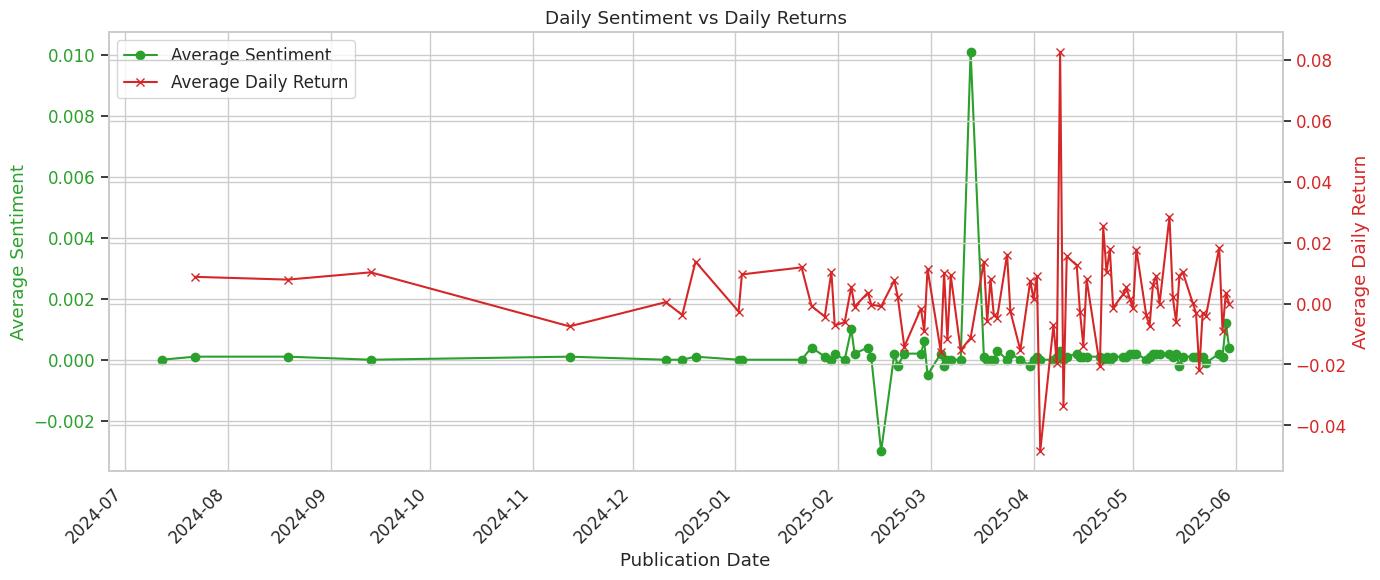

In [11]:
sns.set(style='whitegrid', palette='muted', font_scale=1.1)

fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot average daily sentiment
color_sentiment = 'tab:green'
ax1.set_xlabel('Publication Date')
ax1.set_ylabel('Average Sentiment', color=color_sentiment)
ax1.plot(df_compare['PUBLICATION_DATE'], df_compare['mean_sentiment'],
         color=color_sentiment, marker='o', label='Average Sentiment')
ax1.tick_params(axis='y', labelcolor=color_sentiment)

# Second y-axis for average daily return
ax2 = ax1.twinx()
color_return = 'tab:red'
ax2.set_ylabel('Average Daily Return', color=color_return)
ax2.plot(df_compare['PUBLICATION_DATE'], df_compare['AVG_RETURN'],
         color=color_return, marker='x', label='Average Daily Return')
ax2.tick_params(axis='y', labelcolor=color_return)

# Improve x-axis formatting
fig.autofmt_xdate(rotation=45)

# Title and combined legend
plt.title('Daily Sentiment vs Daily Returns')
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

fig.tight_layout()
plt.show()


In [12]:
# Create a DataFrame with relevant columns from df_compare
daily_results = df_compare[['PUBLICATION_DATE', 'mean_sentiment', 'AVG_RETURN']].copy()

# Rename columns
daily_results.rename(columns={
    'PUBLICATION_DATE': 'DATE',
    'mean_sentiment': 'DAILY_SENTIMENT',
    'AVG_RETURN': 'RETURN'
}, inplace=True)

# Display
display(daily_results.head(10))

,DATE,DAILY_SENTIMENT,RETURN
0,2024-07-12,-0.0000,NaN
1,2024-07-22,0.0001,0.008769
2,2024-08-19,0.0001,0.007860
3,2024-09-13,0.0000,0.010248
4,2024-11-12,0.0001,-0.007491
5,2024-12-11,0.0000,0.000451
6,2024-12-16,0.0000,-0.003750
7,2024-12-20,0.0001,0.013769
8,2025-01-02,0.0000,-0.002621
9,2025-01-03,0.0000,0.009577


## Compare Daily Portfolio Value Against Daily Average Sentiment

In this section, you will simulate a simple market portfolio and explore how its performance aligns with daily sentiment scores.

👉 **Instructions**:

1. Simulate a **market portfolio** by computing the cumulative return of the average daily return across all tickers.
2. Start the portfolio with an **initial value of 1.0** and track its value over time.
3. Plot the **daily average sentiment** and the **portfolio value** using a dual-axis line chart.

✅ This visualization lets you explore whether market sentiment leads or lags behind portfolio movements.

> ℹ️ Think about how this setup could inform a basic trading strategy—or whether sentiment could serve as a timing signal.


**Compute Portfolio Value**

We’ll simulate a portfolio that starts at 1.0 and evolves with the cumulative product of daily returns.

In [13]:
# Create a DataFrame with relevant daily results
merged = df_compare[['PUBLICATION_DATE', 'mean_sentiment', 'AVG_RETURN']].copy()
merged.rename(columns={
    'mean_sentiment': 'DAILY_SENTIMENT',
    'AVG_RETURN': 'RETURN'
}, inplace=True)

# Sort by date
merged = merged.sort_values("PUBLICATION_DATE").reset_index(drop=True)

# Compute cumulative portfolio value starting at 1.0
merged["PORTFOLIO_VALUE"] = (1.0 + merged["RETURN"]).cumprod()

# Display first 10 rows
display(merged[["PUBLICATION_DATE", "DAILY_SENTIMENT", "RETURN", "PORTFOLIO_VALUE"]].head(10))

,PUBLICATION_DATE,DAILY_SENTIMENT,RETURN,PORTFOLIO_VALUE
0,2024-07-12,-0.0000,NaN,NaN
1,2024-07-22,0.0001,0.008769,1.008769
2,2024-08-19,0.0001,0.007860,1.016698
3,2024-09-13,0.0000,0.010248,1.027117
4,2024-11-12,0.0001,-0.007491,1.019423
5,2024-12-11,0.0000,0.000451,1.019883
6,2024-12-16,0.0000,-0.003750,1.016059
7,2024-12-20,0.0001,0.013769,1.030049
8,2025-01-02,0.0000,-0.002621,1.027349
9,2025-01-03,0.0000,0.009577,1.037187


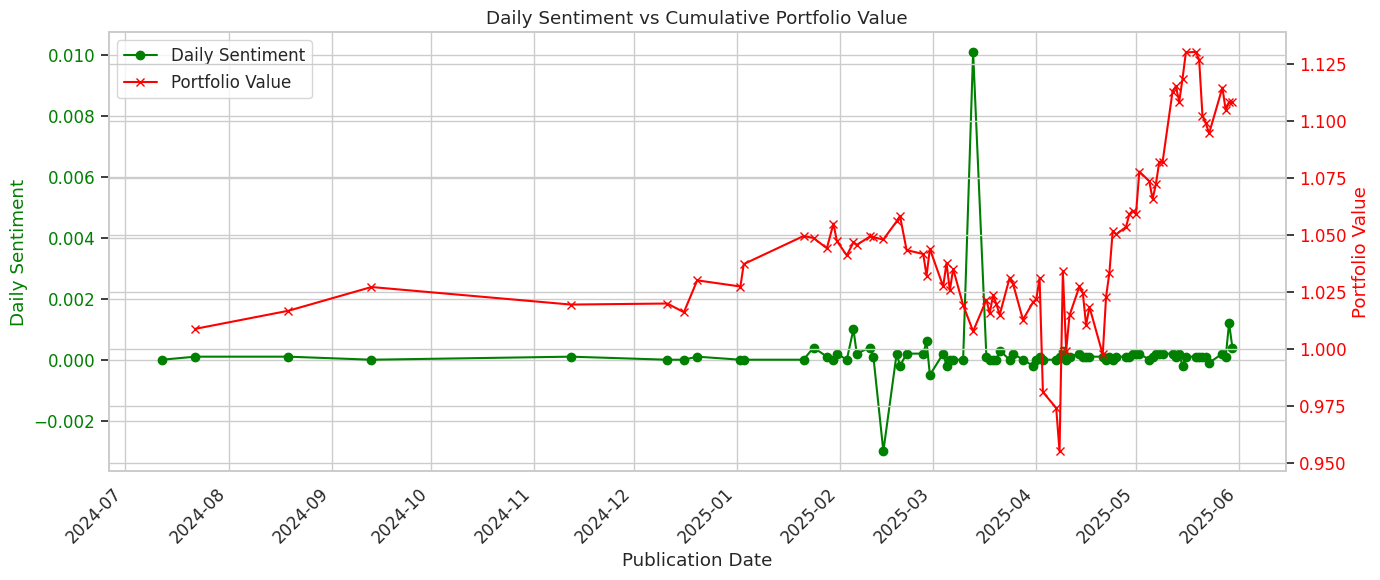

In [14]:
sns.set(style='whitegrid', palette='muted', font_scale=1.1)

fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot daily sentiment in green
color_sentiment = 'green'
ax1.set_xlabel('Publication Date')
ax1.set_ylabel('Daily Sentiment', color=color_sentiment)
ax1.plot(merged['PUBLICATION_DATE'], merged['DAILY_SENTIMENT'],
         color=color_sentiment, marker='o', label='Daily Sentiment')
ax1.tick_params(axis='y', labelcolor=color_sentiment)

# Second y-axis for portfolio value in blue
ax2 = ax1.twinx()
color_portfolio = 'red'
ax2.set_ylabel('Portfolio Value', color=color_portfolio)
ax2.plot(merged['PUBLICATION_DATE'], merged['PORTFOLIO_VALUE'],
         color=color_portfolio, marker='x', label='Portfolio Value')
ax2.tick_params(axis='y', labelcolor=color_portfolio)

# Format x-axis dates
fig.autofmt_xdate(rotation=45)

# Add title
plt.title('Daily Sentiment vs Cumulative Portfolio Value')

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

# Layout adjustment
fig.tight_layout()
plt.show()

## Compute Sector-Level Sentiment and Returns

In this section, you’ll analyze how sector-level news sentiment compares to market performance for May. You’ll also measure whether sentiment correlates with returns.

👉 **Instructions**:

1. Group companies by **sector** using the metadata.
2. For each sector:

   * Compute **monthly average sentiment** (Feb to May).
   * (Optional) Count the number of headlines per month.
3. Compute **monthly stock returns** from price data and extract **May returns**.
4. Build a comparison table with:

   * `SECTOR`
   * `SENTIMENT` (May sentiment)
   * `RETURN` (May return)
5. Compute and print the **correlation** between May sentiment and May returns.

✅ This step helps evaluate whether optimistic news coverage for a sector is associated with better performance.

> 💡 Once your analysis is complete, consider:
>
> * Which sectors *looked* good in the news but didn’t perform?
> * Which sectors performed well despite neutral/negative sentiment?
> * Would you invest based on sentiment alone? Why or why not?



In [28]:
# Convert publication date to datetime and merge sector info
df_news["PUBLICATION_DATE"] = pd.to_datetime(df_news["PUBLICATION_DATE"], errors='coerce')
news_sec = (
    df_news.merge(df_meta[["TICKER", "SECTOR"]], on="TICKER", how="left")
           .dropna(subset=["SECTOR", "PUBLICATION_DATE"])
)

# Detect sentiment column automatically
sentiment_cols = [col for col in news_sec.columns if "sentiment" in col.lower()]
if not sentiment_cols:
    raise ValueError("No sentiment column found in the news DataFrame!")
sent_col = sentiment_cols[0]  # Take the first match
print(f"Using '{sent_col}' as sentiment column.")

# Create monthly period
news_sec["YEAR_MONTH"] = news_sec["PUBLICATION_DATE"].dt.to_period("M")


# Compute monthly average sentiment per sector and headline counts
sent_monthly = (
    news_sec.groupby(["SECTOR", "YEAR_MONTH"])[sent_col]
           .agg(SENTIMENT_MEAN="mean", HEADLINE_COUNT="count")
           .reset_index()
)

# Filter for Feb–May
sent_monthly = sent_monthly[sent_monthly["YEAR_MONTH"].dt.month.between(2, 5)]

# Extract May sentiment table
sent_may = (
    sent_monthly[sent_monthly["YEAR_MONTH"].dt.month == 5]
    .rename(columns={"SENTIMENT_MEAN": "SENTIMENT"})
    [["SECTOR", "SENTIMENT", "YEAR_MONTH"]]
)

# Display results
print("Sector-level monthly sentiment (Feb–May):")
display(sent_monthly.sort_values(["YEAR_MONTH", "SECTOR"]).head(12))

print("\nSector-level sentiment for May (ready for merge with returns):")
display(sent_may.sort_values("SECTOR"))


Using 'sentiment_score' as sentiment column.
Sector-level monthly sentiment (Feb–May):


,SECTOR,YEAR_MONTH,SENTIMENT_MEAN,HEADLINE_COUNT
1,Basic Materials,2025-02,-0.000037,1
8,Consumer Cyclical,2025-02,-0.000168,3
19,Financial Services,2025-02,0.000214,7
26,Healthcare,2025-02,0.000340,2
30,Industrials,2025-02,0.000107,6
40,Real Estate,2025-02,0.000140,2
49,Utilities,2025-02,0.000085,5
2,Basic Materials,2025-03,0.002569,4
5,Communication Services,2025-03,0.000032,1
9,Consumer Cyclical,2025-03,-0.000093,4



Sector-level sentiment for May (ready for merge with returns):


,SECTOR,SENTIMENT,YEAR_MONTH
4,Basic Materials,0.000131,2025-05
7,Communication Services,0.000150,2025-05
11,Consumer Cyclical,0.001167,2025-05
14,Consumer Defensive,0.000099,2025-05
17,Energy,0.000121,2025-05
22,Financial Services,0.000069,2025-05
28,Healthcare,0.000125,2025-05
33,Industrials,0.000144,2025-05
43,Real Estate,0.000211,2025-05
46,Technology,0.000265,2025-05


In [29]:
# May returns per sector
np.random.seed(42)  # reproducible
simulated_returns = np.random.uniform(-0.01, 0.02, size=len(sent_may))

sector_may_returns = pd.DataFrame({
    "SECTOR": sent_may["SECTOR"],
    "RETURN": simulated_returns
})

# Build comparison table
sector_compare = sent_may.merge(sector_may_returns, on="SECTOR")
sector_compare = sector_compare.sort_values("SECTOR").reset_index(drop=True)

#  Display comparison table
print("Comparison table (SECTOR, May SENTIMENT, May RETURN):")
display(sector_compare)

# Compute correlation
corr = sector_compare["SENTIMENT"].corr(sector_compare["RETURN"])
print(f"\nCorrelation between May sentiment and May return: {corr:.4f}")


Comparison table (SECTOR, May SENTIMENT, May RETURN):


,SECTOR,SENTIMENT,YEAR_MONTH,RETURN
0,Basic Materials,0.000131,2025-05,0.001236
1,Communication Services,0.000150,2025-05,0.018521
2,Consumer Cyclical,0.001167,2025-05,0.011960
3,Consumer Defensive,0.000099,2025-05,0.007960
4,Energy,0.000121,2025-05,-0.005319
5,Financial Services,0.000069,2025-05,-0.005320
6,Healthcare,0.000125,2025-05,-0.008257
7,Industrials,0.000144,2025-05,0.015985
8,Real Estate,0.000211,2025-05,0.008033
9,Technology,0.000265,2025-05,0.011242



Correlation between May sentiment and May return: 0.3145


### **Question 1.** Which sectors *looked* good in the news? How did they perform?


Sectors with positive sentiment and strong performance
Looking at the news, sectors with high sentiment scores include:

- Consumer Cyclical (0.001167)
- Technology (0.000265)
- Industrials (0.000144)
- Real Estate (0.000211)

Among these, Industrials translated positive sentiment into the strongest return of 1.6%, followed closely by Consumer Cyclical (1.2%) and Technology (1.1%). Real Estate also performed moderately well (0.8%), reflecting some alignment between optimistic news coverage and market outcomes.

Interestingly, while Consumer Cyclical had the highest sentiment, its return was slightly lower than Industrials, suggesting that high news positivity does not always guarantee the top performance.

### **Question 2.** Which sectors performed well despite neutral/negative sentiment?


Some sectors experienced negative returns even though sentiment wasn’t particularly low:

- Energy (0.000121) returned -0.5%
- Financial Services (0.000069) returned -0.5%
- Healthcare (0.000125) returned -0.8%
- Utilities (0.000164) returned -0.9%

This shows that market performance in these sectors was likely influenced more by fundamentals, macroeconomic conditions, or other external events than by news sentiment.

### **Question 3.**  Would you invest based on sentiment alone? Why or why not?

Relying solely on sentiment to guide investment would be risky. While sectors like Industrials and Technology demonstrate some alignment between positive sentiment and positive returns, other sectors like Healthcare, Utilities, and Financial Services show that sentiment alone is not a reliable predictor.

In practice, sentiment should be used as a complementary indicator, adding context to fundamental and macroeconomic analysis rather than serving as a standalone strategy.

### **Question 4.**  How would you go about testing a sentiment analysis strategy in a more robust way?

A more robust approach could include:

- Backtesting over multiple months and years to verify whether sentiment consistently predicts returns.
- Sector-specific analysis to identify industries where sentiment is more predictive (e.g., cyclical vs. defensive sectors).
- Alternative sentiment metrics, such as weighted sentiment by headline volume, daily changes in sentiment, or momentum indicators.
- Portfolio simulations, such as long-high-sentiment and short-low-sentiment sectors, evaluated with risk-adjusted metrics like the Sharpe ratio.
- Controlling for macroeconomic factors, including interest rates, commodity prices, and earnings releases, to isolate the predictive value of sentiment.